In [19]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from helper_baseline import *
from plots import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
df = pd.read_csv('yelp.csv')

In [29]:
df = df.drop_duplicates()

df['text_clean'] = df['text'].apply(clean_text)

X = df[['text_clean']]
y = df['label']


# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
# CountVectorizer

In [4]:
text_transformer = CountVectorizer(
    ngram_range=(1,2),
    max_features=5000
)

preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, 'text_clean')
    ]
)


# Pipelines

# Logistic Regression (без to_dense)
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# Random Forest (с to_dense)
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('to_dense', FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
    ('model', RandomForestClassifier(random_state=42))
])

# XGBoost (с to_dense)
pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('to_dense', FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
    ('model', XGBClassifier(random_state=42))
])



# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Запуск моделей

models = {
    "LogReg": pipe_lr,
    "RandomForest": pipe_rf,
    "XGBoost": pipe_xgb
}

results_df = evaluate_models_cv(models, X_train, y_train, X_test, y_test, cv)

print("\n📊 CV Results:")
display(results_df)

Test Results:
LogReg: 0.9327
RandomForest: 0.9030
XGBoost: 0.9051

📊 CV Results:


,accuracy,precision,recall,f1,roc_auc
LogReg,0.933744,0.942240,0.946572,0.944362,0.980271
RandomForest,0.898685,0.916485,0.912646,0.914530,0.962825
XGBoost,0.899892,0.911617,0.920874,0.916158,0.965655


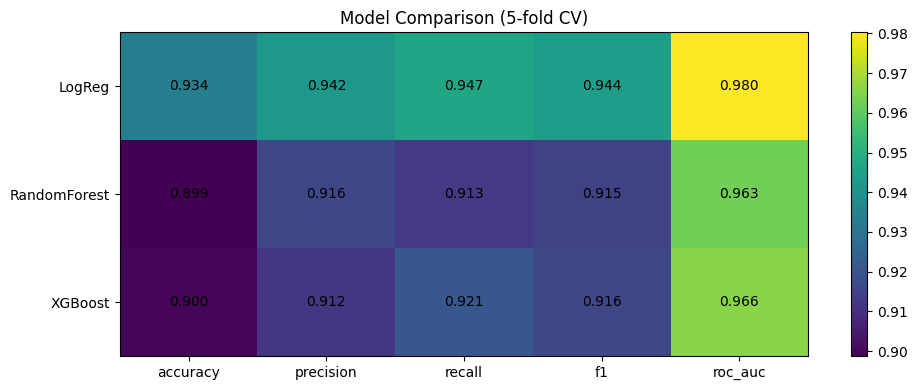

In [5]:
heat_map(results_df)

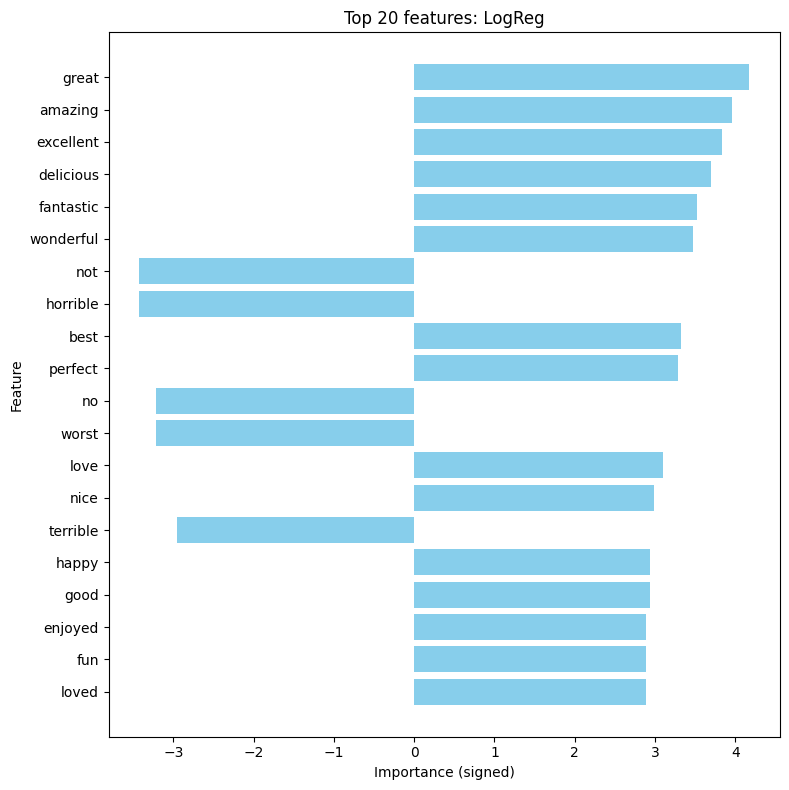

In [11]:
plot_top_features(pipe_lr, "LogReg", top_n=20)

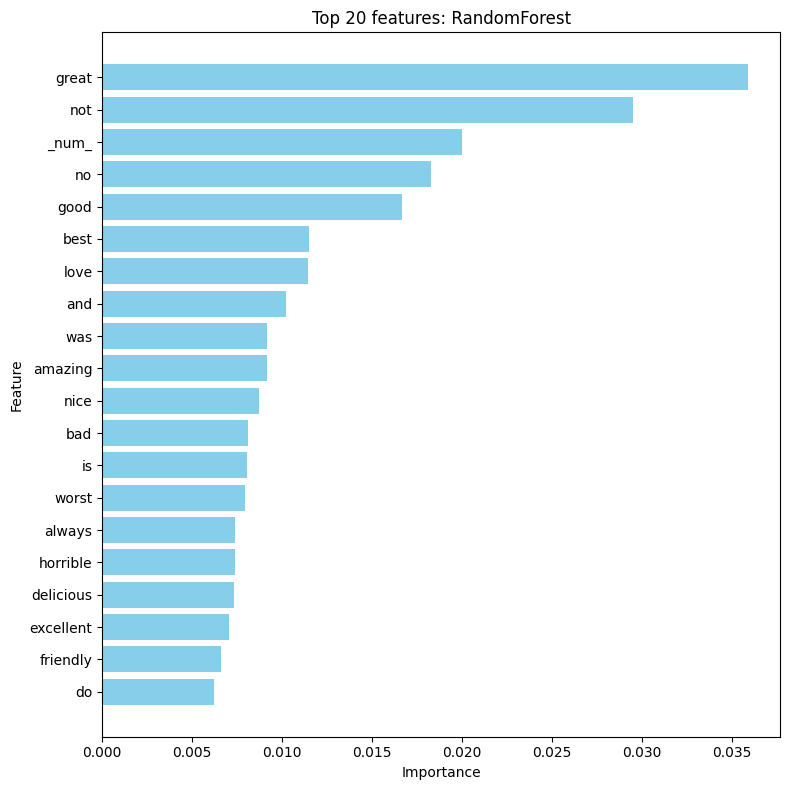

In [15]:
plot_top_features(pipe_rf, "RandomForest", top_n=20)

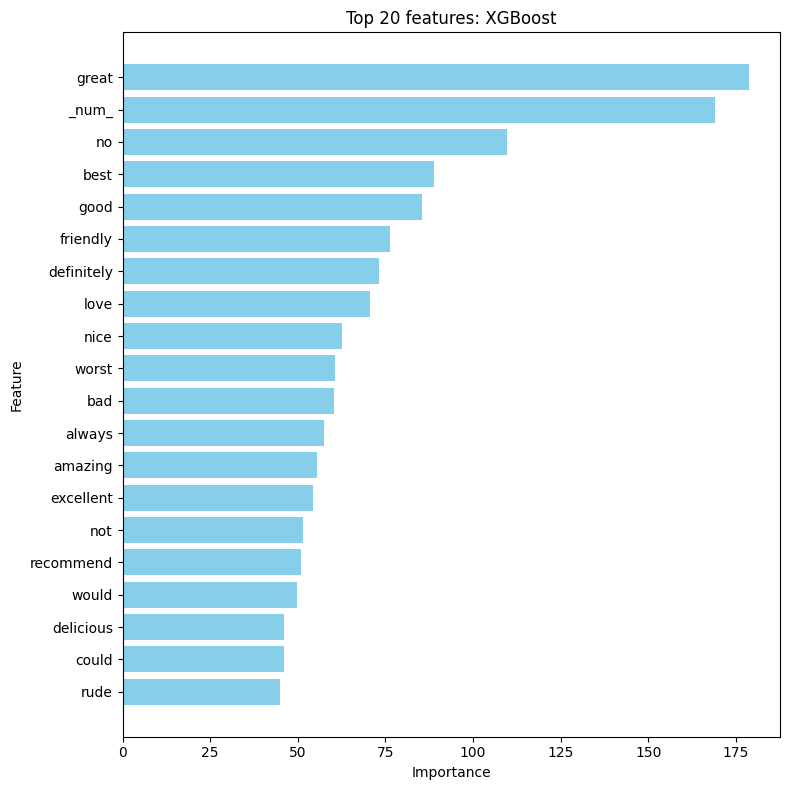

In [17]:
plot_top_features(pipe_xgb, "XGBoost", top_n=20)

In [31]:
# TfidfVecrorizer

In [23]:
text_transformer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000
)

preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, 'text_clean')
    ]
)


# Pipelines

# Logistic Regression (без to_dense)
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# Random Forest (с to_dense)
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('to_dense', FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
    ('model', RandomForestClassifier(random_state=42))
])

# XGBoost (с to_dense)
pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('to_dense', FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
    ('model', XGBClassifier(random_state=42))
])



# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Запуск моделей

models = {
    "LogReg": pipe_lr,
    "RandomForest": pipe_rf,
    "XGBoost": pipe_xgb
}

results_df = evaluate_models_cv(models, X_train, y_train, X_test, y_test, cv)

print("\n📊 CV Results:")
display(results_df)

Test Results:
LogReg: 0.9334
RandomForest: 0.8979
XGBoost: 0.9044

📊 CV Results:


,accuracy,precision,recall,f1,roc_auc
LogReg,0.927770,0.932444,0.947080,0.939680,0.977508
RandomForest,0.894220,0.906241,0.916811,0.911469,0.960493
XGBoost,0.895185,0.921189,0.900660,0.910778,0.963048


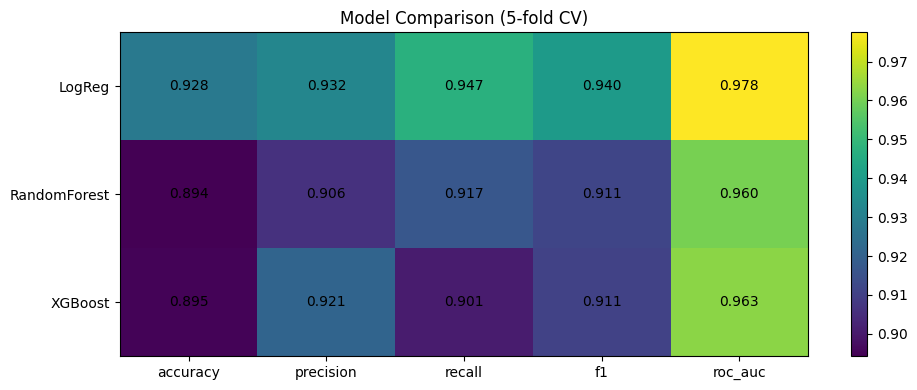

In [24]:
heat_map(results_df)

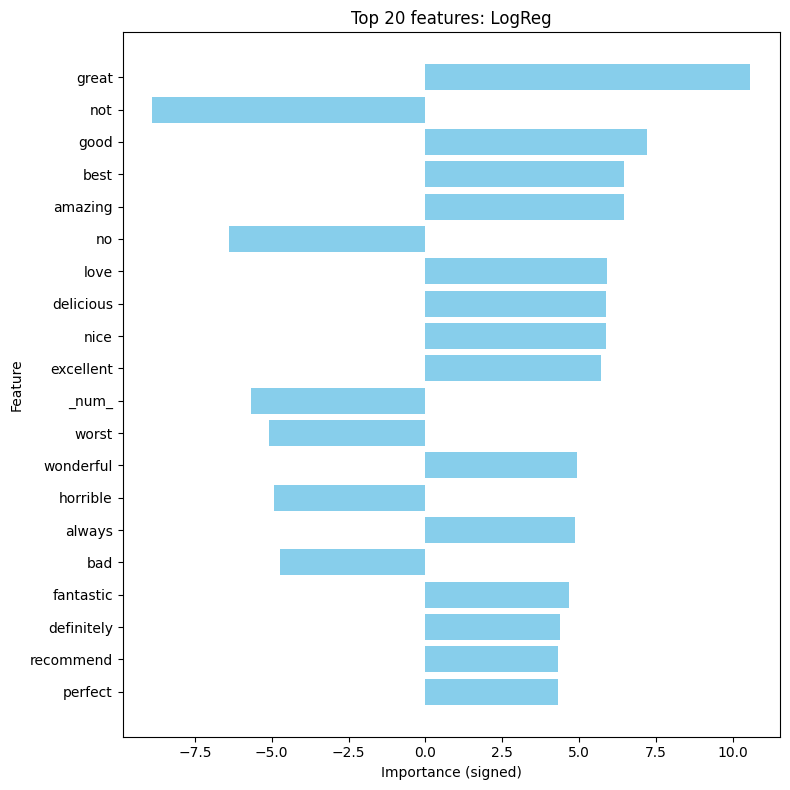

In [25]:
plot_top_features(pipe_lr, "LogReg", top_n=20)

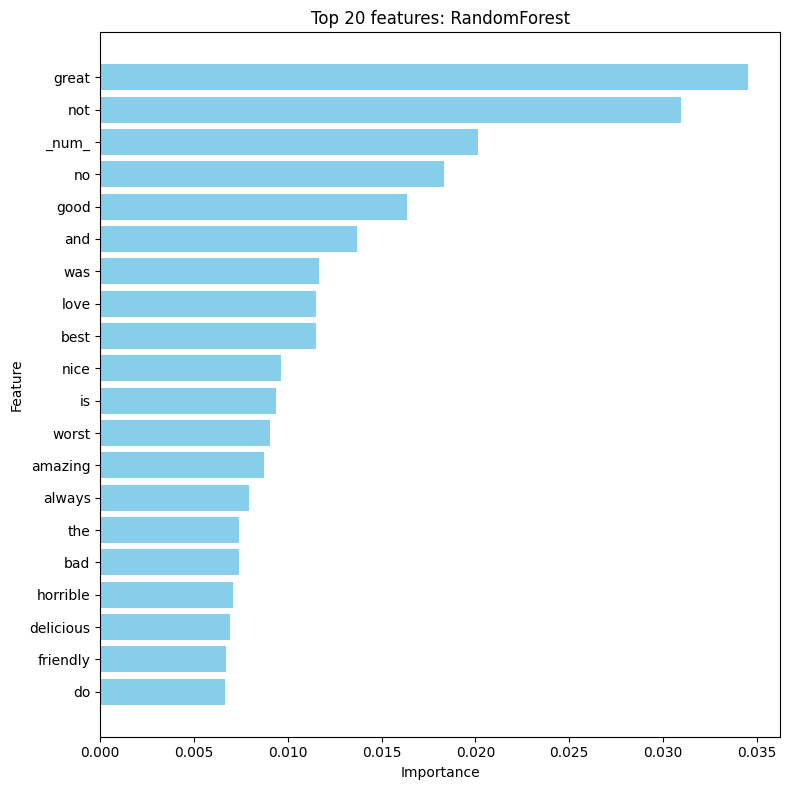

In [26]:
plot_top_features(pipe_rf, "RandomForest", top_n=20)

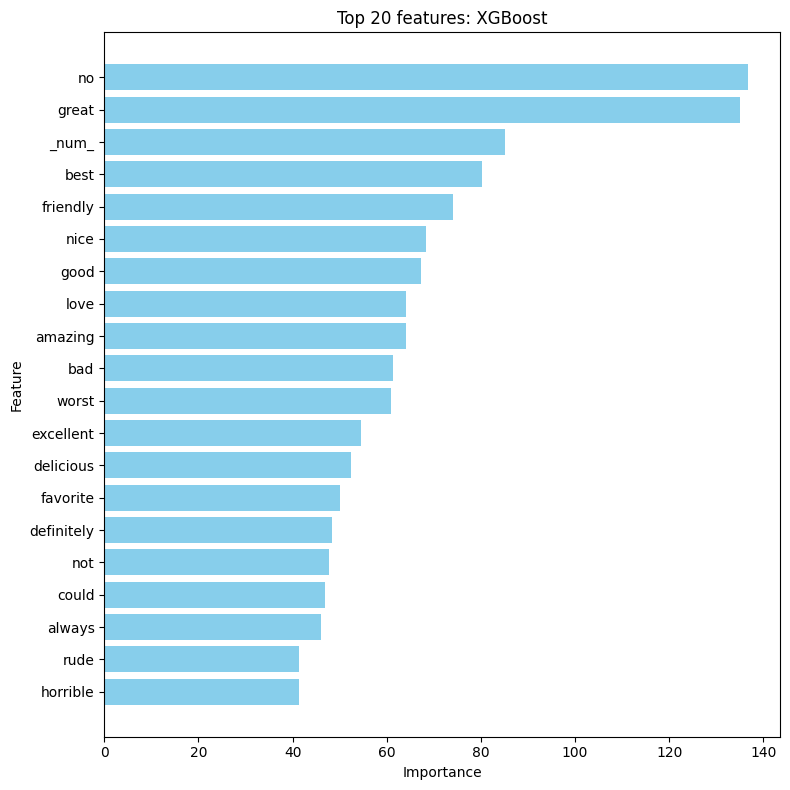

In [27]:
plot_top_features(pipe_xgb, "XGBoost", top_n=20)